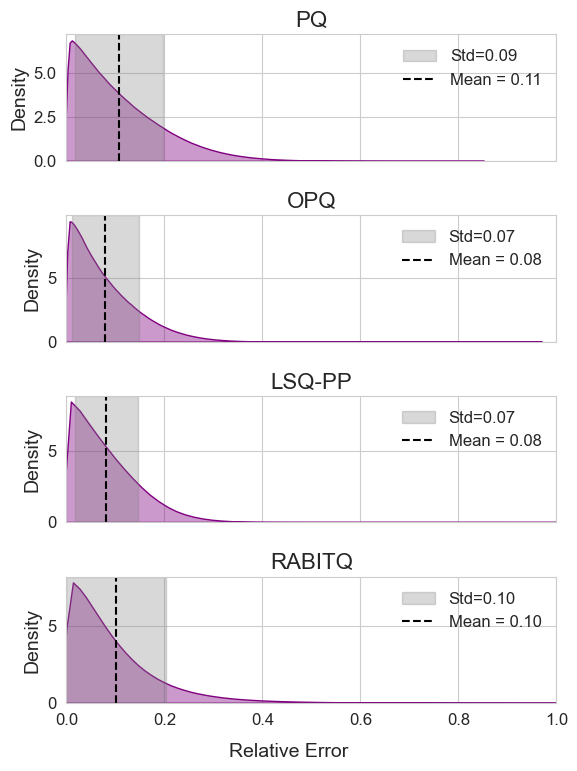

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Path to results directory
base_dir = "/data/cpanourg/2-hdvc/results"

# Define methods and their rel_error.bin paths
methods = {
    "PQ": os.path.join(base_dir, "pq", "rel_error.bin"),
    "OPQ": os.path.join(base_dir, "opq", "rel_error.bin"),
    "LSQ-PP": os.path.join(base_dir, "lsq_pp", "rel_error.bin"),
    "RABITQ": os.path.join(base_dir, "rabitq", "rel_error.bin")
}

# Styling
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,             # larger font for paper readability
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
sns.set_style("whitegrid")

# Create compact figure
fig, axes = plt.subplots(len(methods), 1, figsize=(6, 8), sharex=True)

for ax, (method_name, path) in zip(axes, methods.items()):
    # Load binary relative error file
    rel_error = np.fromfile(path, dtype=np.float32)
    rel_error = rel_error[np.isfinite(rel_error)]  # Clean NaNs/Infs

    mean_rel, std_rel = rel_error.mean(), rel_error.std()

    # KDE plot
    sns.kdeplot(rel_error, fill=True, color="purple", alpha=0.4, ax=ax)

    # Shade ±1 std region (more evident)
    ax.axvspan(mean_rel - std_rel, mean_rel + std_rel, color="grey", alpha=0.3, label=f"Std={std_rel:.2f}")

    # Mean line
    ax.axvline(mean_rel, linestyle="--", color="black", label=f"Mean = {mean_rel:.2f}")

    # Labels and title
    ax.set_xlim(0, 1)
    ax.set_ylabel("Density")
    ax.set_title(f"{method_name}", pad=6)

    # Simplify legend (upper right, no box)
    ax.legend(frameon=False, loc="upper right")

# Common X label
fig.text(0.5, 0.04, "Relative Error", ha="center", fontsize=14)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
